In [6]:
# --- imports & environment ---
import sys
import pathlib
import itertools

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import iv

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams['font.size'] = 9
plt.rcParams['mathtext.fontset'] = 'cm'

In [7]:
# get TAP data

import json

dnames = ["tap_Pe0_train2", "tap_Pe0p01", "tap_Pe0p03","tap_Pe0p1","tap_Pe0p3",
            "tap_Pe1","tap_Pe3","tap_Pe10","tap_Pe30","tap_Pe100"]
S0 = 31.6774
S1_zdot = []
S1_dot = []
S1_div = []
for dname in dnames:
    with open(f"../runs/{dname}/entropy/summary.json", "r") as f:
        summary = json.load(f)
    #print(summary['S_prior'])
    #print(summary['batches']['zdot']['S_target'])
    S1_zdot.append(summary['batches']['zdot']['S_target'])

tap_S_ex = np.array(S1_zdot) - S0
Pe = np.array([0,0.01,0.03,0.1,0.3,1,3,10,30,100])



In [8]:
# get XY data

energies = np.load("XY/xy_ener.npy")
entropies = np.load("XY/xy_entr.npy")
chain_lengths   = np.array([1,2,4,8,16,32,64])
free_energies = energies - entropies

N_train = 10
ener_train = -1.23193
ent_train = 0.49887
free_train = ener_train + ent_train

J = 2
Nspace = np.linspace(1,2*np.amax(chain_lengths),1000)
ds = ((Nspace-1)/Nspace) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
de = ((Nspace-1)/Nspace) * (-J*(iv(1,J)/iv(0,J)))
df = de - ds



In [9]:
# Get LJ Data

htot = np.load("LJ/lj13_B256_hist_cold_1m.npy")
hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*htot))

def smooth(v, k=100):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v


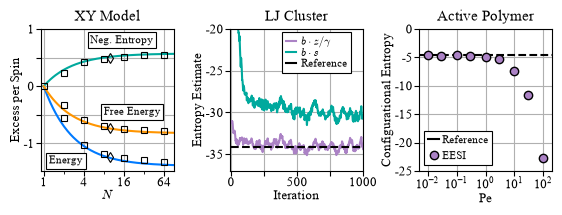

In [10]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)
plt.rcParams['axes.unicode_minus'] = False

fig,axs = plt.subplots(1,3,figsize=(5.5,2))

axs[0].set_prop_cycle(plt.cycler(color=okabe_ito))
axs[0].plot(Nspace,-ds,label=r'$-\Delta \tilde{s}$',ms=5,lw=1.5,color="#00A99D")
axs[0].plot(Nspace,de,label=r"$\Delta \tilde{u}$",ms=5,lw=1.5,color='#007aff')
axs[0].plot(Nspace,df,label=r"$\Delta \tilde{f}$",ms=5,lw=1.5,color="#ff9500")

axs[0].plot(chain_lengths[1:],energies[1:],'ks',mfc='none',mew=0.8,ms=4.5)
axs[0].plot(chain_lengths[1:],-entropies[1:],'ks',mfc='none',mew=0.8,ms=4.5)
axs[0].plot(chain_lengths[1:],free_energies[1:],'ks',mfc='none',mew=0.8,ms=4.5)
axs[0].plot(1,0,'ks',mfc='none',mew=0.8,ms=4.5)

axs[0].plot(N_train,ener_train,'kd',mfc='none',ms=5,mew=0.8)
axs[0].plot(N_train,ent_train,'kd',mfc='none',ms=5,mew=0.8)
axs[0].plot(N_train,free_train,'kd',mfc='none',ms=5,mew=0.8)

axs[0].set_xscale('log')
axs[0].set_xticks([1,4,16,64])
axs[0].set_xticks([2,8,32],minor=True)
axs[0].set_xlim(0.9,1.4*np.amax(chain_lengths))

axs[0].xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%d"))
axs[0].yaxis.set_minor_formatter(matplotlib.ticker.ScalarFormatter())

axs[0].set_xlabel(r'$N$',labelpad=1)
axs[0].set_ylabel('Excess per Spin',labelpad=1)
axs[0].set_yticks([-1,-0.5,0,0.5,1],["-1","","0","","1"])
#axs[0].set_yticks([-0.5,0.5], minor=True)
plt.setp(axs[0].get_yminorticklabels(), visible=False)
axs[0].set_title("XY Model")
axs[0].tick_params(axis='y', pad=1)
axs[0].tick_params(axis='x', pad=1)

bbox_properties = dict(
    boxstyle="square,pad=0.25",  # Shape of the box (e.g., 'square', 'round')
    facecolor="white",         # Background color
    edgecolor="k",           # Border color
    linewidth=0.8,               # Border thickness
    alpha=1.0                  # 1.0 = Fully opaque background
)

axs[0].text(5,0.75,"Neg. Entropy",fontsize=8,bbox=bbox_properties)
axs[0].text(1.2,-1.35,"Energy",fontsize=8,bbox=bbox_properties)
axs[0].text(8,-0.5,"Free Energy",fontsize=8,bbox=bbox_properties)
axs[0].grid()


# LJ Cluster
axs[1].set_prop_cycle(plt.cycler(color=okabe_ito[3:]))
axs[1].plot(smooth(ent_zdot,25),'-',lw=1.5,label=r"$b \cdot z / \gamma$",color="#ab82c5")
axs[1].plot(smooth(ent_dot,25),'-',lw=1.5,label=r"$b \cdot s$",color="#00A99D")
axs[1].set_ylabel("Entropy Estimate",labelpad=1)
axs[1].set_xlabel("Iteration",labelpad=1)
axs[1].set_xticks([0,250,500,750,1000],["0","","500","","1000"])
#axs[1].set_xticks([250,750],minor=True)
axs[1].hlines(-34.17,0,25000,linestyles=["dashed"],colors=["k"],lw=1.5)
axs[1].plot([-1e4,1e4], [34.17,34.17],"-k",lw=1.5,label='Reference')
axs[1].set_xlim(-10,1000)
axs[1].set_ylim(-37,-20)
axs[1].tick_params(axis='y', pad=1)
axs[1].tick_params(axis='x', pad=1)
axs[1].set_title("LJ Cluster")
leg = axs[1].legend(fontsize=8, edgecolor = "k", fancybox = False,
                framealpha=1.0, markerscale=1,
                borderpad=0.35,
                handletextpad=0.45,
                handlelength=0.95,
                labelspacing=0.0,
                loc=(0.39,0.69))
leg.get_frame().set_linewidth(0.8)
axs[1].grid()

# Active Polymer

axs[2].set_prop_cycle(plt.cycler(color=okabe_ito[5:]))
axs[2].hlines(-4.607,5e-3,200,ls='--',lw=1.5,color="k")
axs[2].plot([-1e4,1e4], [4.607,4.607],"-k",lw=1.5,label='Reference')
axs[2].plot(Pe,tap_S_ex,'o',label="EESI",mfc="#ab82c5",mec='k',ms=6)
axs[2].set_xscale('log')
axs[2].set_xlabel('Pe',labelpad=1)
axs[2].set_ylabel('Configurational Entropy',labelpad=1)
axs[2].set_ylim(-25,0)
axs[2].set_xlim(5e-3,200)
axs[2].set_title("Active Polymer")
axs[2].set_xticks([0.01,0.1,1,10,100])
leg = axs[2].legend(fontsize=8, edgecolor = "k", fancybox = False,
                framealpha=1.0, markerscale=1,
                borderpad=0.35,
                handletextpad=0.3,
                handlelength=0.95)
leg.get_frame().set_linewidth(0.8)
axs[2].tick_params(axis='y', pad=1)
axs[2].tick_params(axis='x', pad=1)
axs[2].grid()

plt.subplots_adjust(0.06,0.16,0.99,0.87,wspace=0.42)
#plt.tight_layout()

plt.savefig("eesi.pdf",dpi=600)
plt.savefig("eesi.png",dpi=600)
plt.savefig("eesi.eps",dpi=600)
plt.show()